In [18]:
import torch 
import numpy as np 
import h5py
import os
from pathlib import Path
import importlib
import IPython.display as ipd
from corpus.speaker_room_dataset import SpeakerRoomDataset
import src.audio_transforms as at
import scipy.stats as stats

import src.spatial_attn_lightning as binaural_lightning 
import yaml
from pytorch_lightning import Trainer
from tqdm.auto import tqdm

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [55]:
### Get most recent config
config_path = "config/binaural_attn/word_task_half_co_loc_v07.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v07/checkpoints/epoch=2-step=46074.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['hparas']['batch_size'] = 2 # config['data']['loader']['batch_size'] // args.gpus
config['noise_kwargs']['low_snr'] = 0
config['num_workers'] = 2
config['noise_kwargs']['high_snr'] = 0
# get model input sr for brir resampling
signal_sr = config['audio']['rep_kwargs']['sr']
coch_sr = config['audio']['rep_kwargs']['env_sr']
cue_duration = 0.5
n_cue_frames = int(cue_duration * signal_sr)
config['model']['n_cue_frames'] = n_cue_frames


In [56]:
config['audio']['rep_kwargs']

{'sr': 44100,
 'env_sr': 10000,
 'n_channels': 40,
 'low_lim': 40,
 'use_pad': True,
 'binaural': True,
 'rep_on_gpu': True,
 'center_crop': True,
 'out_dur': 2,
 'impulse_len': 0.25,
 'env_extraction_type': 'Half-wave Rectification',
 'downsampling_type': 'TorchTransformsResample',
 'downsampling_kwargs': {'lowpass_filter_width': 64,
  'rolloff': 0.9475937167399596,
  'resampling_method': 'kaiser_window',
  'beta': 14.769656459379492}}

In [57]:
x = torch.randn(1,8, 20)
x[:,:, 0:5] = 0
x[:,:, 15:] = 0


In [58]:
mask = x != 0
((x * mask).sum(-1) / mask.sum(-1))

tensor([[-0.3151, -0.3216, -0.4268, -0.0314, -0.1034, -0.3730,  0.3256,  0.1121]])

In [59]:
model = binaural_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=False)
model = model.eval()
coch_gram = model.coch_gram.cuda()

num_classes={'num_words': 800}
Model performing word task
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


In [60]:
dataset = SpeakerRoomDataset(manifest_path='/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl',
                            excerpt_path='/om2/user/msaddler/spatial_audio_pipeline/assets/swc/manifest_all_words.pdpkl',
                            cue_type='voice_and_location',
                            sr=signal_sr) 


diotic_transforms = at.AudioCompose([
                    at.AudioToTensor(),
                    at.CombineWithRandomDBSNR(low_snr=0, high_snr=0), 
                    at.RMSNormalizeForegroundAndBackground(rms_level=0.02),  # 0.02 is the default for CV-based models 
                    at.DuplicateChannel(),

            ])


diotic_transforms = diotic_transforms.cuda()


def single_signal_collate_fn(batch):
    #apply transforsms to batch
    cues = torch.stack([diotic_transforms(cue, None)[0] for cue, fg, bg, label, confusion in batch])
    mixtures = torch.stack([diotic_transforms(fg, bg)[0] for cue, fg, bg, label, confusion in batch]).type(torch.FloatTensor)
    labels = torch.tensor([label for cue, fg, bg, label, confusion in batch]).type(torch.LongTensor)
    confusion = torch.tensor([confusion for cue, fg, bg, label, confusion in batch]).type(torch.LongTensor)
    return cues, mixtures, labels, confusion


dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=False, num_workers=config['num_workers'], collate_fn=single_signal_collate_fn)


In [63]:
# torch module to center crop the cochleagram to a given duration 
class CenterCropCoch(torch.nn.Module):
    def __init__(self, crop_duration, sig_duration, sr):
        super().__init__()
        self.n_crop_frames = int(crop_duration * sr)
        sig_frames = int(sig_duration * sr)
        self.crop_start = (sig_frames - self.n_crop_frames) // 2
        self.crop_end = self.crop_start + self.n_crop_frames
        self.pad_start = self.crop_start
        self.pad_end = sig_frames - self.crop_end

    def forward(self, x):
        # crop x to n_crop_frames and zero pad back to original length
        cropped = x[..., self.crop_start:self.crop_end]
        return torch.nn.functional.pad(cropped, (self.pad_start, self.pad_end), 'constant', 0)

        # x_frames = x.shape[-1]
        # crop_start = (x_frames - self.n_crop_frames) // 2
        # crop_end = crop_start + self.n_crop_frames
        # cropped = x[..., crop_start:crop_end]
        # # pad back to original length
        # pad_start = crop_start
        # pad_end = x_frames - crop_end
        # return torch.nn.functional.pad(cropped, (pad_start, pad_end), 'constant', 0)



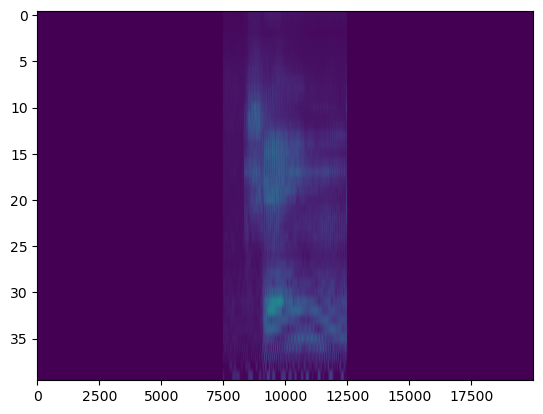

In [70]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.imshow(cue[0][0].cpu().numpy(), aspect='auto', origin='upper')

In [64]:
output_dict = {'results': None, 'confusions': None}
accuracies = []
pred_list = []
true_word_int = []
confusions_list  = []
all_probs_of_interest = []
guessed_both = []
ix = 0 

center_crop = CenterCropCoch(cue_duration, coch_sr).cuda() 
with torch.no_grad(): 
    for batch in tqdm(dataloader):
        # if ix > 10:
        #     break
        cue, mixture, label, confusion = batch
        # cue, fg, label = batch
        # just running diotically on fg 
        # cue, _ = audio_transforms(cue.cuda(), None)
        # mixture, _ = diotic_transforms(fg.cuda().squeeze(), None)
        # cue = cue.cuda()
        # mixture = mixture.cuda()
        cue, mixture = coch_gram(cue.cuda(), mixture.cuda())
        cue = center_crop(cue)
        # cue_mask_ixs = torch.arange(cue.shape[0])
        logits = model(cue, mixture, None)
        probs = logits.softmax(dim=-1).cpu().detach().numpy()

        # get top 2 probs for each example
        top_2_probs = torch.topk(logits.softmax(-1), 5, dim=-1).indices.cpu().detach().numpy()
        return_both = (np.isin(label.numpy(), top_2_probs) * np.isin(confusion.numpy(), top_2_probs)).astype('int')
        
        targ_probs = probs[torch.arange(probs.shape[0]), label]
        conf_probs = probs[torch.arange(probs.shape[0]), confusion]
        probs_of_interest = np.concatenate([targ_probs[:, None], conf_probs[:, None]], axis=1)

        preds = logits.softmax(dim=-1).argmax(dim=-1).cpu().detach().numpy().astype('int')
        true_word = label.numpy().astype('int')
        accuracy = (preds == true_word).astype('int')
        conf = (preds == confusion.numpy().astype('int')).astype('int')
        confusions_list.append(conf)
        accuracies.append(accuracy)
        pred_list.append(preds)
        true_word_int.append(true_word)
        all_probs_of_interest.append(probs_of_interest)
        guessed_both.append(return_both)
        ix += 1 
        
accuracies = np.concatenate(accuracies)
pred_list = np.concatenate(pred_list)
true_word_int = np.concatenate(true_word_int)
confusions_list = np.concatenate(confusions_list)
all_probs_of_interest = np.concatenate(all_probs_of_interest, axis=0)
guessed_both = np.concatenate(guessed_both)

output_dict['probs_of_interest'] = all_probs_of_interest
output_dict['results'] = accuracies
output_dict['preds'] = pred_list
output_dict['true_word_int'] = true_word_int

print(f"Using cue duration of {cue_duration} seconds")
print(f"Accuracy using fg as cue: {np.mean(accuracies):.2f}, ({stats.sem(accuracies):.2f})")
print(f"Confusions using fg as cue: {np.mean(confusions_list):.2f}, ({stats.sem(confusions_list):.2f})")
print(f"Guessed both talker words: {np.mean(guessed_both):.2f}, ({stats.sem(guessed_both):.2f})")

5000


100%|██████████| 198/198 [03:16<00:00,  1.01it/s]

Using cue duration of 0.5 seconds
Accuracy using fg as cue: 0.00, (0.00)
Confusions using fg as cue: 0.00, (0.00)
Guessed both talker words: 0.00, (0.00)


Using cue duration of 2 seconds    
Accuracy using fg as cue: 0.56, (0.01)    
Confusions using fg as cue: 0.09, (0.00)    
Guessed both talker words: 0.12, (0.01)    

Using cue duration of 0.1 seconds    
Accuracy using fg as cue: 0.50, (0.01)    
Confusions using fg as cue: 0.09, (0.01)    
Guessed both talker words: 0.11, (0.01)

In [25]:
# print(f"Using cue duration of {cue_duration} seconds")
# print(f"Accuracy using fg as cue: {np.mean(accuracies):.2f}, ({stats.sem(accuracies):.2f})")
# print(f"Confusions using fg as cue: {np.mean(confusions_list):.2f}, ({stats.sem(confusions_list):.2f})")
# print(f"Guessed both talker words: {np.mean(guessed_both):.2f}, ({stats.sem(guessed_both):.2f})")